# PERTEMUAN 7 - Regresi Linier

**Nama Lengkap**: Nabila Oktaviani Wibowo

**NIM**: 230401010239

**Kelas**: IF405


# Tujuan Praktikum

1. Memahami konsep Regresi Linear.
2. Melakukan preprocessing data.
3. Melatih model Machine Learning.
4. Mengevaluasi model menggunakan MAE, RMSE, dan R².

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0,20,n)
edu = np.random.choice([0,1,2], n)

kota = np.random.choice(
    ['Jakarta','Surabaya','Bandung'],
    n
)

gaji = (
    3.0 +
    2.2 * pengalaman +
    1.5 * edu +
    np.where(kota=='Jakarta',4.0,0) +
    np.random.normal(0,2,n)
)

df = pd.DataFrame({
    'pengalaman':pengalaman,
    'edu':edu,
    'kota':kota,
    'gaji':gaji
})

df.head()

,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


In [4]:
print(df.shape)
df.describe()

(300, 4)


,pengalaman,edu,gaji
count,300.000000,300.000000,300.000000
mean,9.904092,0.886667,27.401294
std,5.886811,0.826296,13.406371
min,0.101232,0.000000,1.672200
25%,4.781616,0.000000,16.242495
50%,10.234355,1.000000,27.974936
75%,15.137192,2.000000,38.894143
max,19.801077,2.000000,54.223931


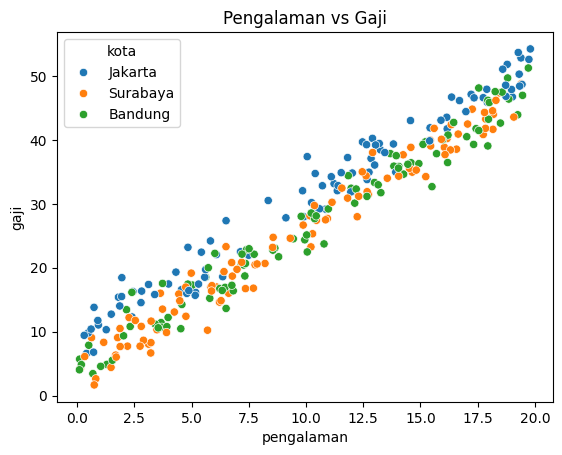

In [5]:
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota'
)

plt.title('Pengalaman vs Gaji')
plt.show()

In [6]:
df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

df.head()

,pengalaman,edu,gaji,kota_Jakarta,kota_Surabaya
0,7.490802,0,21.953247,1,0
1,19.014286,1,46.721665,1,0
2,14.639879,2,34.952649,0,1
3,11.973170,2,32.437143,0,0
4,3.120373,2,17.384265,1,0


In [7]:
X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [9]:
model = LinearRegression()

model.fit(X_train_s, y_train)

LinearRegression()

In [10]:
print("Intercept:", model.intercept_)
print("Koefisien:", model.coef_)

Intercept: 27.514124756898322
Koefisien: [13.04224099  1.1878795   1.83722613 -0.29156083]


In [11]:
coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": model.coef_
})

coef_df.sort_values(
    "Koefisien",
    ascending=False
)

,Fitur,Koefisien
0,pengalaman,13.042241
2,kota_Jakarta,1.837226
1,edu,1.187879
3,kota_Surabaya,-0.291561


In [12]:
y_pred = model.predict(X_test_s)

In [14]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(
    y_test,
    y_pred
)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.6492396276312633
RMSE: 2.1228816522586875
R2  : 0.973959044815968


## Interpretasi Metrik

- MAE menunjukkan rata-rata kesalahan prediksi model.
- RMSE memberikan penalti lebih besar terhadap error besar.
- R² menunjukkan persentase variasi data yang berhasil dijelaskan model.

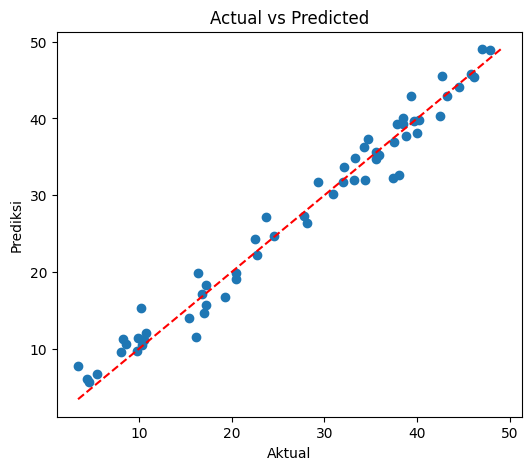

In [15]:
plt.figure(figsize=(6,5))

plt.scatter(y_test,y_pred)

lims = [
    min(y_test.min(),y_pred.min()),
    max(y_test.max(),y_pred.max())
]

plt.plot(lims,lims,'r--')

plt.xlabel("Aktual")
plt.ylabel("Prediksi")
plt.title("Actual vs Predicted")

plt.show()

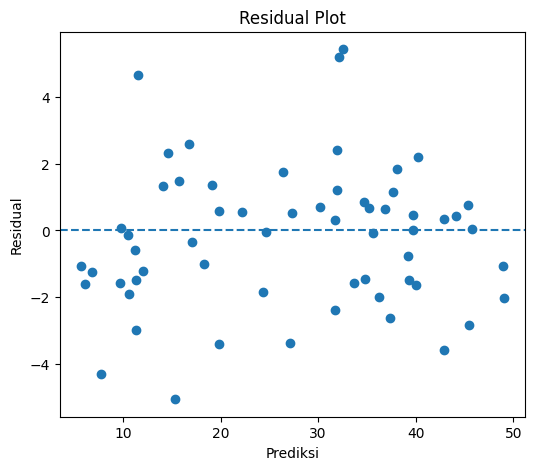

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred,residuals)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Prediksi")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

## Analisis Plot

### Actual vs Predicted
What:
Titik-titik mendekati garis diagonal.

So What:
Model mampu menghasilkan prediksi yang cukup baik.

Now What:
Model dapat ditingkatkan dengan menambah fitur baru.

### Residual Plot
What:
Residual tersebar di sekitar nol.

So What:
Asumsi linearitas relatif terpenuhi.

Now What:
Lakukan eksperimen dengan algoritma lain untuk membandingkan performa.

# Kesimpulan

Pada praktikum ini saya mempelajari proses pembangunan model Machine Learning menggunakan Regresi Linear mulai dari pembuatan dataset, preprocessing, training model, evaluasi, dan visualisasi hasil.

Temuan utama:
- Pengalaman kerja memiliki pengaruh positif terhadap gaji.
- Model menghasilkan nilai R² yang cukup tinggi sehingga mampu menjelaskan sebagian besar variasi data.
- MAE dan RMSE menunjukkan kesalahan prediksi relatif kecil.

Keterbatasan:
- Dataset yang digunakan masih sintetis.
- Model hanya menggunakan Regresi Linear sehingga belum dibandingkan dengan algoritma lain.

Pertanyaan lanjutan:
- Bagaimana performa model jika menggunakan Random Forest atau XGBoost?
- Apakah penambahan fitur baru dapat meningkatkan nilai R²?